# analysis.detection-statistics


## Summary 

In this notebook, we focus on the numbers generated by our bacteria-taxonomic profiling using MOTUs. We read mostly content from the `metadata.site-library.csv` files and from `hits.bacteria.csv`. We first carry out a bacteria / PAB based analysis, and then we carry out a library based analysis. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import taxoniq
from daforfer import DaforferDB
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                name                │                                                                                  description                                                                                   │
│              varchar               │                                                                                    varchar                                                                                     │
├────────────────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_bacteriaHits                     │ This table contains all the MOTUS hits obtained, regardless of their status. It contains the libr

## Bacteria

We carry out the analysis here by making questions and answering them.

### How many bacteria were detected?

To know that, first we need to load the data. 

In [2]:
bacteria_hits = db.conn.sql('SELECT * FROM D_bacteriaHits').df()
metadata = db.conn.sql('SELECT * FROM D_sites').df()

Now, we value count the different taxids. 

In [3]:
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_hits

,site,library,habitat,n_extracts,host_taxon,taxid,scientific_name,is_pab,pab_type
0,C1,PV534,Crop,3,Diplotaxis erucoides,59620,uncultured Clostridium sp.,False,
1,C1,PV535,Crop,17,Brassica oleracea,1563157,Pseudomonas endophytica,True,pab_unknown
2,C1,PV535,Crop,17,Brassica oleracea,1270,Micrococcus luteus,True,pab_unknown
3,C1,PV535,Crop,17,Brassica oleracea,59620,uncultured Clostridium sp.,False,
4,C1,PV538,Crop,8,Brassica oleracea,82995,Serratia grimesii,False,
...,...,...,...,...,...,...,...,...,...
1512,Z2,PV529,Crop,1,Picris echioides,289370,Pseudomonas argentinensis,True,pab_unknown
1513,Z2,PV529,Crop,1,Picris echioides,1736265,Methylobacterium sp. Leaf125,True,pab_unknown
1514,Z2,PV529,Crop,1,Picris echioides,91844,Candidatus Portiera aleyrodidarum,False,
1515,Z2,PV529,Crop,1,Picris echioides,1192054,Paracoccus sp. 228,False,


The data contains hits. We need to aggregate the hits to get the OTUs to which they map, which we do by a simple `value_counts`. 

In [4]:
bacteria_hits_count = bacteria_hits.value_counts(['taxid', 'scientific_name']).reset_index()
bacteria_hits_count['rank'] = 1 + np.arange(len(bacteria_hits_count))
bacteria_hits_count['%'] = bacteria_hits_count['count'] / len(bacteria_hits)
bacteria_hits_count

,taxid,scientific_name,count,rank,%
0,59620,uncultured Clostridium sp.,258,1,0.173620
1,1736282,Frigoribacterium sp. Leaf164,26,2,0.017497
2,1828,Rhodococcoides fascians,21,3,0.014132
3,1747,Cutibacterium acnes,21,4,0.014132
4,243924,Pseudomonas lutea,21,5,0.014132
...,...,...,...,...,...
517,67304,Streptomyces griseorubiginosus,1,518,0.000673
518,866564,Polaromonas glacialis,1,519,0.000673
519,861266,Pseudarthrobacter siccitolerans,1,520,0.000673
520,758825,Rugamonas rubra,1,521,0.000673


In [5]:
bacteria_hits_count.query('scientific_name == ""')

,taxid,scientific_name,count,rank,%
29,332410,,8,30,0.005384
430,300020,,1,431,0.000673
481,1050843,,1,482,0.000673


In [6]:
print("Total hits {:6d}".format(len(bacteria_hits))) # 1486
print(" |--> corresponding to {:6d} bacterial OTUs".format(len(bacteria_hits_count))) # 522


Total hits   1486
 |--> corresponding to    522 bacterial OTUs


We have 1486 hits corresponding to 519 OTUs. Now, let's see how they distribute. 

In [8]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(bacteria_hits_count.query('count == 1'))}, # 311
        {"threshold": ">1", "count": len(bacteria_hits_count.query('count > 1'))}, # 211
        {"threshold": ">2", "count": len(bacteria_hits_count.query('count > 2'))}, # 113 
        {"threshold": ">5", "count": len(bacteria_hits_count.query('count > 5'))}, # 43
        {"threshold": ">10", "count": len(bacteria_hits_count.query('count > 10'))}, # 22
    ]
)



,threshold,count
0,=1,311
1,>1,211
2,>2,113
3,>5,43
4,>10,22


Most OTUs (> 300) have been detected only one. A ranking map of these OTUs should help us see this pattern. In the folllowing plot, we are sorting by growing rank the OTUs depending on their number of hits. On the left, we would find the OTUs with higher number of hits, on the right those with the lower number of hits. 

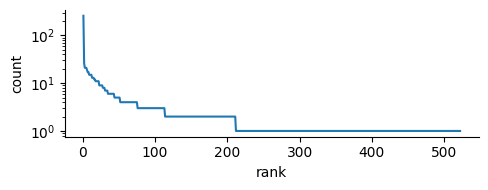

In [10]:
g = sns.relplot(
    data=bacteria_hits_count, y='count', x='rank', kind='line',
    height=2.0, aspect=2.5
)
# g.ax.axvline(10, linestyle='--', color='gray')
g.ax.set_yscale('log')


We can observe indeed a very heterogeneous distribution, with some hits exceeding the 100 detections. Let's see which could be these organisms.

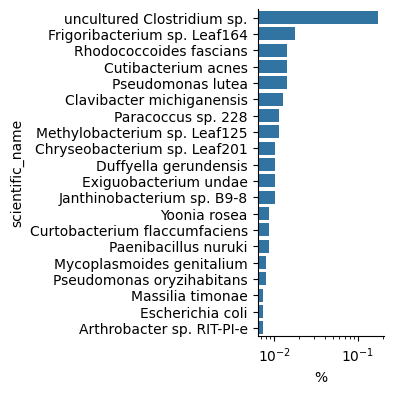

In [11]:
g = sns.catplot(
    data=bacteria_hits_count[:20], y='scientific_name', x='%', kind='bar', height=4.0, aspect=1.0
)
g.ax.set_xscale('log')

This is quite interesting:
- The most abundant organism is an *uncultured Clostridium sp.*. This means that it could be whatever.
- After that one, we have some organism that are indeed known for interacting with plants such as *Pseudomonas lutea*.
- We also find unexpected items, such as *Escherichia coli* and *Mycoplasmoides genitalium*. This could mean that our samples are either contaminated by animal associated bacteria.

#### Conclussion

- 1486 hits
- 522 OTUs
- Very heterogeneous distribution
- There are some unexpected organisms

### How many bacteria are plant-associated-bacteria?

The way to solve this query is very easy: just remove the bacteria that are not PAB, and repeat the whole analysis. 

In [12]:
bacteria_hits_count = bacteria_hits.query('is_pab == True').value_counts(['taxid', 'scientific_name', 'pab_type']).reset_index()
bacteria_hits_count['rank'] = 1 + np.arange(len(bacteria_hits_count))
bacteria_hits_count['%'] = bacteria_hits_count['count'] / len(bacteria_hits.query('is_pab == True'))
bacteria_hits_count

,taxid,scientific_name,pab_type,count,rank,%
0,1736282,Frigoribacterium sp. Leaf164,pab_unknown,26,1,0.060046
1,243924,Pseudomonas lutea,pab_unknown,21,2,0.048499
2,1828,Rhodococcoides fascians,pab_unknown,21,3,0.048499
3,1736265,Methylobacterium sp. Leaf125,pab_unknown,17,4,0.039261
4,1735672,Chryseobacterium sp. Leaf201,pab_unknown,15,5,0.034642
...,...,...,...,...,...,...
122,1144319,Herbaspirillum sp. CF444,pab_unknown,1,123,0.002309
123,1144310,Rhizobium sp. CF080,pab_symbiont,1,124,0.002309
124,1028989,Pseudomonas sp. StFLB209,pab_unknown,1,125,0.002309
125,582680,Microbacterium azadirachtae,pab_unknown,1,126,0.002309


In [13]:
print("Total PAB hits {:6d}".format(len(bacteria_hits.query('is_pab == True')))) # 433
print(" |--> corresponding to {:6d} PAB OTUs".format(len(bacteria_hits_count))) # 127


Total PAB hits    433
 |--> corresponding to    127 PAB OTUs


We have a total of 433 PAB hits, corresponding to 127 OTUs. These numbers might have been slightly higher in the past, given some errors when counting organisms. Let's take again one look at the count.

In [14]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(bacteria_hits_count.query('count == 1'))},# 53 
        {"threshold": ">1", "count": len(bacteria_hits_count.query('count > 1'))}, # 74
        {"threshold": ">2", "count": len(bacteria_hits_count.query('count > 2'))}, #45
        {"threshold": ">5", "count": len(bacteria_hits_count.query('count > 5'))}, # 20
        {"threshold": ">10", "count": len(bacteria_hits_count.query('count > 10'))}, # 9
    ]
)

,threshold,count
0,=1,53
1,>1,74
2,>2,45
3,>5,20
4,>10,9


The numbers are quite brutal again. Two fifths of the data have only one positive hit. Let's look at this again with a rank-plot. 

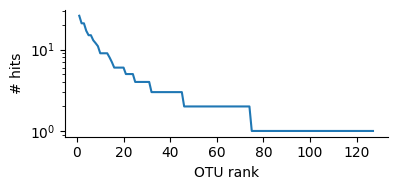

In [15]:
g = sns.relplot(
    data=bacteria_hits_count, y='count', x='rank', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("OTU rank")
g.set_ylabels("# hits")

g.savefig("figures/rankplot.pab-bacteria.svg")

Now we can take a quick look at the composition of these bacteria.

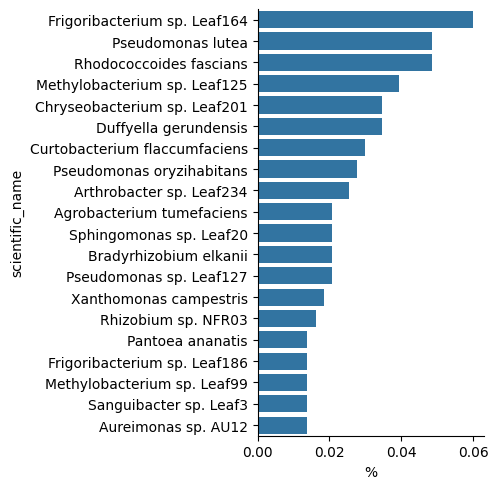

In [16]:
g = sns.catplot(
    data=bacteria_hits_count[:20], y='scientific_name', x='%', kind='bar'
)
# g.ax.set_xscale('log')

### What is the high-level taxonomic composition of our PABs?

While we have the species represented in the plot above, higher-taxonomy levels might provide another picture. We will use Taxoniq to compute the taxon, class, order, etc of each of the taxa, and we will dump it in a figure. 

In [17]:
bacteria_hits_count['taxon'] = bacteria_hits_count['taxid'].apply(lambda x: taxoniq.Taxon(x))
bacteria_hits_count['class'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'class'][0])
bacteria_hits_count['order'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'order'][0])
bacteria_hits_count['phylum'] = bacteria_hits_count['taxon'].apply(lambda x: [item.scientific_name for item in x.ranked_lineage if item.rank.name == 'phylum'][0])

The following figure should represent the phylum (color) and the order (row) of all the species detected. 

Saved P_PABtaxonomy to 2025-10-21


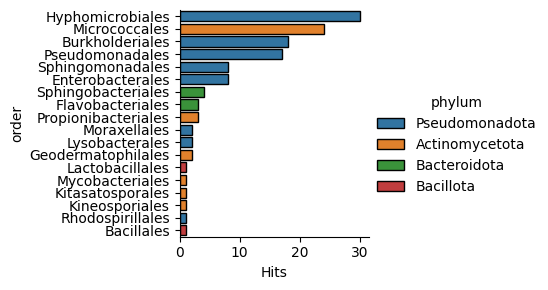

In [18]:
bacteria_taxonomies = bacteria_hits_count.value_counts(['order', 'phylum']).reset_index()

db.save_dataframe(
    bacteria_taxonomies, table_name="P_PABtaxonomy",
    description="Number of PAB hits belonging to each different phylum and order"
)
g = sns.catplot(bacteria_taxonomies, x='count', hue='phylum', y='order', kind='bar', edgecolor='black', height=3., aspect=1.5, dodge=False)
g.set_xlabels("Hits")
g.savefig("figures/catplot.detections-taxonomic-composition.colbyphyla.svg")

### What kind of PABs?

Sanchis et al. (2021) consider three types of PABs:
- *symbionts*, which we prefer to call *mutualists*
- *pathogens*, which we should call *antagonists* —but we won't.
- *unknown*, those that have an uncertain relationship with the hosts.

We are going to generate a table the considers the numbers of each of these PAB types among our OTUs.

In [19]:
pab_types = bacteria_hits_count.value_counts(['pab_type']).reset_index().rename(columns={'count': 'OTUs'})
db.save_dataframe(
    pab_types, table_name="D_PABTypeCounts",
    description="Occurrences of the different kinds of PABs"
)
pab_types

Saved D_PABTypeCounts to 2025-10-21


,pab_type,OTUs
0,pab_unknown,96
1,pab_symbiont,17
2,pab_pathogen,14


### How are the different PABs distributed?

We will generate a file that can be used as a table in the supplementary material, where bacteria are associated to their host ranges, PAB type, and number of hits. 

First, we will compute the host range, using the `host_taxon`, `taxid` and `scientific_name` as keys, and then counting by `scientific_name` and `taxid`. This should tell us how many different hosts can each entry find.  

In [20]:
bacteria_host_range = bacteria_hits.query('is_pab == True').value_counts(
    ['host_taxon', 'scientific_name', 'taxid']
    ).reset_index().value_counts(
        ['scientific_name', 'taxid']
    ).reset_index().rename(columns={'count': 'host_range'})
assert(len(bacteria_host_range) == 127) # INTRODUCING THIS KIND OF CHECKS CAN HELP US CHECKING OUR OPERATIONS
bacteria_host_range

,scientific_name,taxid,host_range
0,Frigoribacterium sp. Leaf164,1736282,22
1,Pseudomonas lutea,243924,16
2,Rhodococcoides fascians,1828,15
3,Methylobacterium sp. Leaf125,1736265,14
4,Duffyella gerundensis,1619313,14
...,...,...,...
122,Erwinia mallotivora,69222,1
123,Enterobacter kobei,208224,1
124,Duganella sp. CF458,1884368,1
125,Duganella sp. CF402,1855289,1


Now, we will count the number of hits per habitat. To do so, we simply do a value counts of the hits sharing `taxid,scientific_name,habitat`, and then we pivot the dataset to get it columns.

In [21]:
bacteria_pab_perhabitat = bacteria_hits.query('is_pab == True').value_counts(["taxid", "scientific_name", "habitat"]).reset_index() 
bacteria_pab_perhabitat = bacteria_pab_perhabitat.pivot(index=['scientific_name', 'taxid'], columns='habitat', values='count').fillna(0).reset_index()
assert(len(bacteria_pab_perhabitat) == 127)
bacteria_pab_perhabitat


habitat,scientific_name,taxid,Crop,Edge,Oak,Wasteland
0,Achromobacter xylosoxidans,85698,1.0,1.0,0.0,0.0
1,Acidovorax sp. Leaf160,1736280,0.0,0.0,0.0,1.0
2,Acidovorax sp. Leaf78,1736237,0.0,0.0,0.0,1.0
3,Acinetobacter baumannii,470,1.0,0.0,0.0,0.0
4,Acinetobacter pittii,48296,2.0,1.0,0.0,0.0
...,...,...,...,...,...,...
122,Stutzerimonas stutzeri,316,0.0,1.0,0.0,1.0
123,Variovorax paradoxus,34073,0.0,0.0,1.0,1.0
124,Xanthomonas campestris,339,0.0,4.0,0.0,4.0
125,Xaviernesmea rhizosphaerae,1672749,1.0,0.0,0.0,0.0


A slightly more complex query consists on getting the host-ranges per habitat. To do so, we need to first deduplicate the bacteria-hit dataset by `scientific_name,taxid,host_taxon,habitat`, and then repeat. 

In [22]:
bacteria_pab_hrperhabitat = bacteria_hits.query('is_pab == True').drop_duplicates(
    ["taxid", "scientific_name", "host_taxon", "habitat"]
).value_counts(
    ["taxid", "scientific_name", "habitat"]
).reset_index() 
bacteria_pab_hrperhabitat = bacteria_pab_hrperhabitat.pivot(index=['scientific_name', 'taxid', ], columns='habitat', values='count').fillna(0).reset_index()
assert(len(bacteria_pab_hrperhabitat) == 127)
bacteria_pab_hrperhabitat


habitat,scientific_name,taxid,Crop,Edge,Oak,Wasteland
0,Achromobacter xylosoxidans,85698,1.0,1.0,0.0,0.0
1,Acidovorax sp. Leaf160,1736280,0.0,0.0,0.0,1.0
2,Acidovorax sp. Leaf78,1736237,0.0,0.0,0.0,1.0
3,Acinetobacter baumannii,470,1.0,0.0,0.0,0.0
4,Acinetobacter pittii,48296,2.0,1.0,0.0,0.0
...,...,...,...,...,...,...
122,Stutzerimonas stutzeri,316,0.0,1.0,0.0,1.0
123,Variovorax paradoxus,34073,0.0,0.0,1.0,1.0
124,Xanthomonas campestris,339,0.0,3.0,0.0,4.0
125,Xaviernesmea rhizosphaerae,1672749,1.0,0.0,0.0,0.0


Now, we will compute site-ranges: the number of different sites that are reached by each bacteria.

In [23]:
bacteria_pab_sr = bacteria_hits.query('is_pab == True').drop_duplicates(
    ["taxid", "scientific_name", "site"]
).value_counts(
    ["taxid", "scientific_name"]
).reset_index().rename(columns={'count': 'site_range'})
# bacteria_pab_sr = bacteria_pab_sr.pivot(index=['scientific_name', 'taxid', ], columns='site', values='count').fillna(0).reset_index()
assert(len(bacteria_pab_sr) == 127)
bacteria_pab_sr


,taxid,scientific_name,site_range
0,243924,Pseudomonas lutea,13
1,1736282,Frigoribacterium sp. Leaf164,10
2,1828,Rhodococcoides fascians,9
3,1736265,Methylobacterium sp. Leaf125,9
4,1619313,Duffyella gerundensis,7
...,...,...,...
122,1144319,Herbaspirillum sp. CF444,1
123,1144310,Rhizobium sp. CF080,1
124,1028989,Pseudomonas sp. StFLB209,1
125,582680,Microbacterium azadirachtae,1


Finally, we compute the number of habitats

In [24]:
bacteria_pab_habitatr = bacteria_hits.query('is_pab == True').drop_duplicates(
    ["taxid", "scientific_name", "habitat"]
).value_counts(
    ["taxid", "scientific_name"]
).reset_index().rename(columns={'count': 'habitat_range'})
# bacteria_pab_sr = bacteria_pab_sr.pivot(index=['scientific_name', 'taxid', ], columns='site', values='count').fillna(0).reset_index()
assert(len(bacteria_pab_habitatr) == 127)
bacteria_pab_habitatr


,taxid,scientific_name,habitat_range
0,1736265,Methylobacterium sp. Leaf125,4
1,243924,Pseudomonas lutea,4
2,1619313,Duffyella gerundensis,4
3,1736282,Frigoribacterium sp. Leaf164,4
4,2035,Curtobacterium flaccumfaciens,4
...,...,...,...
122,1230476,Bradyrhizobium sp. DFCI-1,1
123,1144319,Herbaspirillum sp. CF444,1
124,1144310,Rhizobium sp. CF080,1
125,1028989,Pseudomonas sp. StFLB209,1


Now, we can try to merge it all.

In [25]:
pab_distribution = pd.merge(
    bacteria_hits.value_counts(['scientific_name', 'taxid', 'pab_type']).reset_index().rename(columns={'count': 'hits'}),
    bacteria_host_range,
    on=['taxid', 'scientific_name']
)
pab_distribution = pd.merge(
    pab_distribution, bacteria_pab_habitatr, on=['taxid', 'scientific_name']
)

pab_distribution = pd.merge(
    pab_distribution, bacteria_pab_sr, on=['taxid', 'scientific_name']
)

pab_distribution = pd.merge(
    pab_distribution, bacteria_pab_hrperhabitat.rename(columns={'Crop': 'Crop_HR', 'Edge': 'Edge_HR', 'Oak': 'Oak_HR', 'Wasteland': 'Wasteland_HR'}), 
    on=['taxid', 'scientific_name']
)

pab_distribution = pd.merge(
    pab_distribution, bacteria_pab_perhabitat.rename(columns={'Crop': 'Crop_hits', 'Edge': 'Edge_hits', 'Oak': 'Oak_hits', 'Wasteland': 'Wasteland_hits'}), 
    on=['taxid', 'scientific_name']
)

assert(len(pab_distribution)==127)
pab_distribution['pab_type'] = pab_distribution['pab_type'].apply(
    lambda x: {'pab_unknown': 'U', 'pab_symbiont': 'M', 'pab_pathogen': 'P'}[x]
)
pab_distribution

,scientific_name,taxid,pab_type,hits,host_range,habitat_range,site_range,Crop_HR,Edge_HR,Oak_HR,Wasteland_HR,Crop_hits,Edge_hits,Oak_hits,Wasteland_hits
0,Frigoribacterium sp. Leaf164,1736282,U,26,22,4,10,2.0,11.0,1.0,10.0,2.0,13.0,1.0,10.0
1,Pseudomonas lutea,243924,U,21,16,4,13,1.0,5.0,8.0,6.0,1.0,5.0,9.0,6.0
2,Rhodococcoides fascians,1828,U,21,15,3,9,3.0,11.0,0.0,3.0,3.0,15.0,0.0,3.0
3,Methylobacterium sp. Leaf125,1736265,U,17,14,4,9,1.0,4.0,3.0,8.0,1.0,4.0,4.0,8.0
4,Chryseobacterium sp. Leaf201,1735672,U,15,13,2,6,0.0,4.0,0.0,10.0,0.0,4.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,Azospirillum lipoferum,193,U,1,1,1,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
123,Arthrobacter sp. OY3WO11,1835723,U,1,1,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
124,Arthrobacter sp. SPG23,1610703,U,1,1,1,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
125,Microbacterium ginsengisoli,400772,U,1,1,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Testing

We have performed many operations at once. It is therefore convenient to check that the values that we are observing add up. Below, we will run a few tests.

In [26]:
# TEST 1: No organism should have a host range larger than the host range that we had measured 
# at one of the habitats. 
for i in range(len(pab_distribution)):
    example = pab_distribution.loc[i]
    try:
        assert(max([example.Crop_HR,example.Edge_HR, example.Oak_HR,example.Wasteland_HR]) <= example.host_range)
    except AssertionError: 
        print("{0} did not pass the test 1".format(example['scientific_name']))

In [27]:
for i in range(len(pab_distribution)):
    example = pab_distribution.loc[i]
    example_subset = bacteria_hits.query("taxid == {0}".format(example.taxid))
    assert(len(example_subset) == int(example.Crop_hits + example.Edge_hits + example.Wasteland_hits + example.Oak_hits))
    assert(len(example_subset) == int(example.hits))
    assert(len(example_subset.drop_duplicates(['host_taxon'])) == example.host_range)
print("All tests passed! :-D")

All tests passed! :-D


#### Output

This table will be quite useful, so we will save it in a few different formats:

1. CSV to open it later.
2. Excel, to create a single multi-sheet document that eases the writing and the analysis by third parties.

In [28]:
db.save_dataframe(
    pab_distribution, table_name="D_PABOTUs",
    description="This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc."
)
# pab_distribution.sort_values(by='scientific_name').to_csv("output/table.PAB-distribution.csv", sep=";")
# with pd.ExcelWriter('output/MIRIPVIR25.xlsx') as writer:  
#     pab_distribution.sort_values(by='scientific_name').to_excel(writer, sheet_name='PAB-distribution')

Saved D_PABOTUs to 2025-10-21


#### Visualization

Matrix visualizations can be helpful to visualize all this data.

**Visualization of detection per habitat**. Dark tiles mean positive detection at that habitat. 

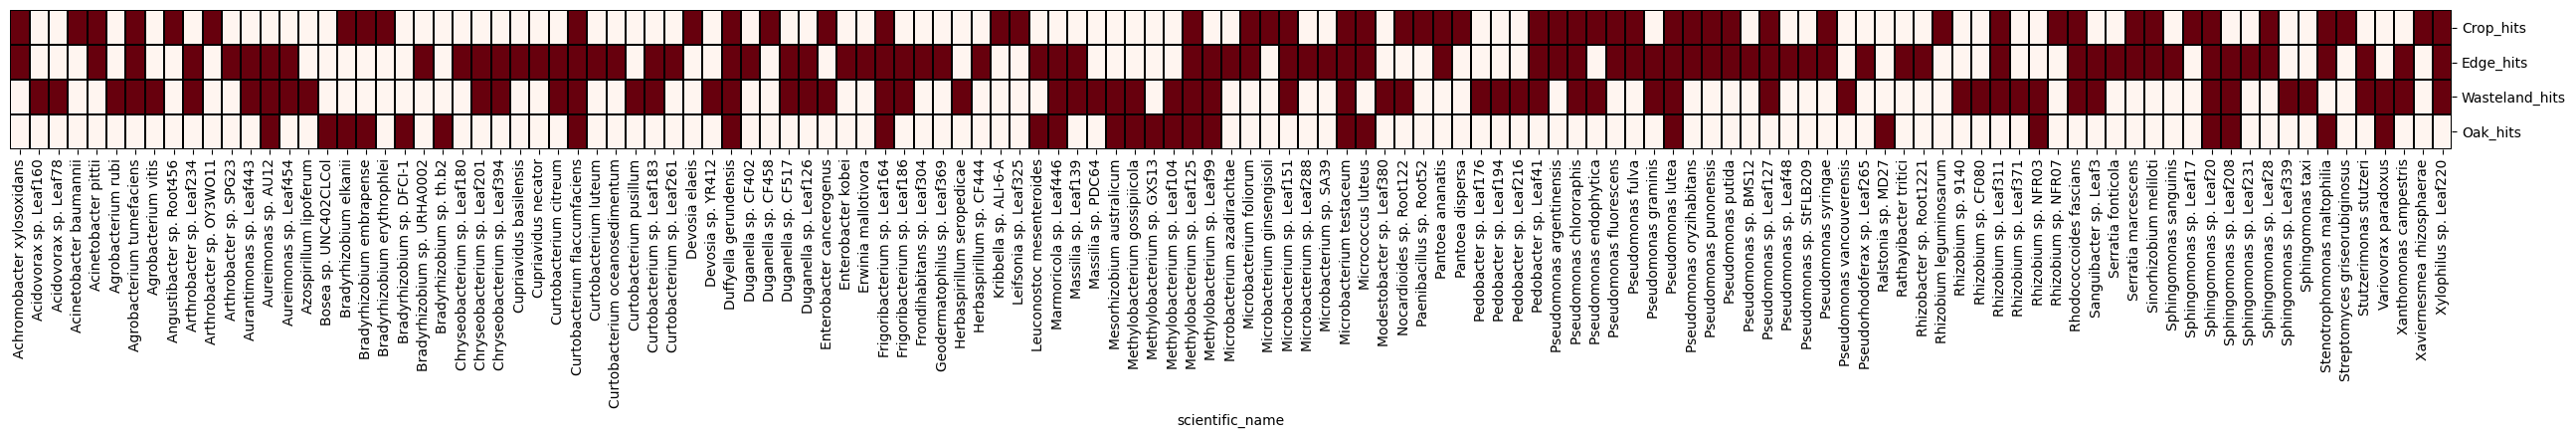

In [29]:
g = sns.clustermap(
    pab_distribution.sort_values(by='scientific_name').set_index('scientific_name')[['Crop_hits', 'Edge_hits', 'Wasteland_hits', 'Oak_hits']].T, cmap='Reds', row_cluster=False,
    col_cluster=False, cbar_pos=None, figsize=(26, 4.5), dendrogram_ratio=(0,0), linecolor='black', linewidth=0.1, vmax=1
)

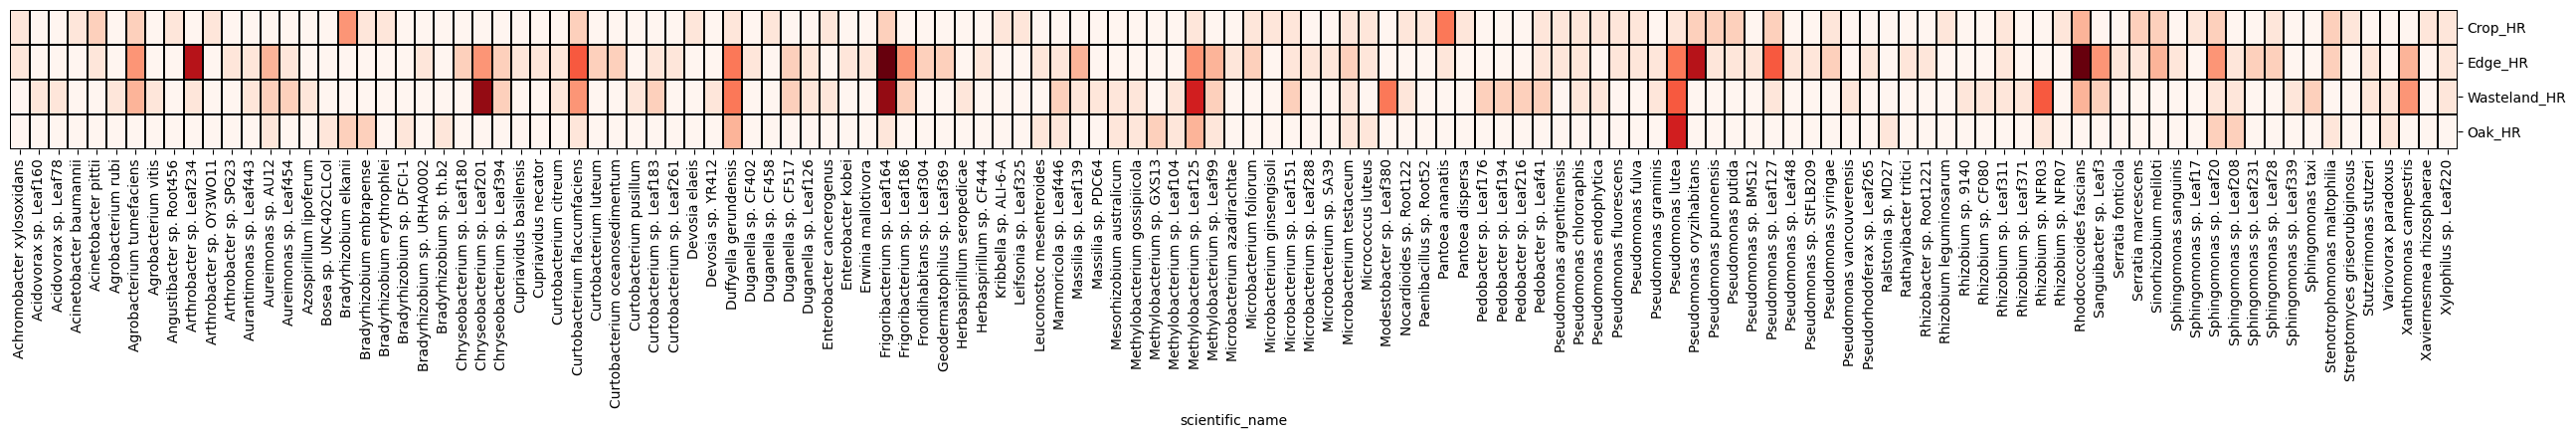

In [30]:
g = sns.clustermap(
    pab_distribution.sort_values(by='scientific_name').set_index('scientific_name')[['Crop_HR', 'Edge_HR', 'Wasteland_HR', 'Oak_HR']].T, cmap='Reds', row_cluster=False,
    col_cluster=False, cbar_pos=None, figsize=(26, 4.5), dendrogram_ratio=(0,0), linecolor='black', linewidth=0.1#, vmax=1
)

#### Are PAB types more widely spread?

With our current data, we can easily visualize whether PAB types might hold different host ranges or number of hits

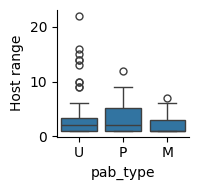

In [31]:
g = sns.catplot(data=pab_distribution, x='pab_type', y='host_range', kind='box', height=2.0)
g.set_ylabels('Host range')

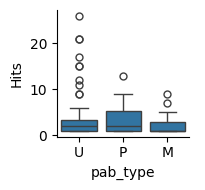

In [32]:
g = sns.catplot(data=pab_distribution, x='pab_type', y='hits', kind='box', height=2.0)
g.set_ylabels('Hits')

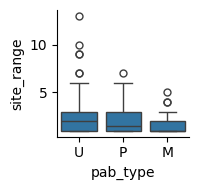

In [33]:
sns.catplot(data=pab_distribution, x='pab_type', y='site_range', kind='box', height=2.0)
g.set_ylabels('Site range')

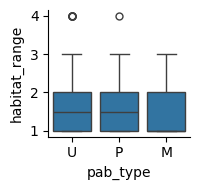

In [34]:
sns.catplot(data=pab_distribution, x='pab_type', y='habitat_range', kind='box', height=2.0)
g.set_ylabels('Habitat range')

We could test these questions statistically, but in general if there is any effect, it seems weak. 

## Libraries

Again, simple Q & A

### What is the distribution of hits across our libraries?

To answer this question, first we need to value-count the number of total hits per library. We all save the habitat. 

In [35]:
library_hits_count = bacteria_hits.value_counts(['library', 'site', 'habitat']).reset_index()
library_hits_count['rank'] = np.arange(len(library_hits_count))
library_hits_count

,library,site,habitat,count,rank
0,PV215,L3,Edge,139,0
1,PV527,Z2,Crop,105,1
2,PV078,E4,Wasteland,71,2
3,PV212,L3,Edge,52,3
4,PV218,L3,Edge,43,4
...,...,...,...,...,...
294,PV118,L1,Edge,1,294
295,PV123,L1,Edge,1,295
296,PV233,L4,Edge,1,296
297,PV126,L1,Edge,1,297


The following table indicates some values of the distribution.

In [36]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(library_hits_count.query('count == 1'))}, #88
        {"threshold": ">1", "count": len(library_hits_count.query('count > 1'))}, #211
        {"threshold": ">2", "count": len(library_hits_count.query('count > 2'))},
        {"threshold": ">5", "count": len(library_hits_count.query('count > 5'))},
        {"threshold": ">10", "count": len(library_hits_count.query('count > 10'))},
    ]
)



,threshold,count
0,=1,88
1,>1,211
2,>2,133
3,>5,58
4,>10,22


We have 299 positive libraries out of the 323 libraries, which means 24 negatives. Only 22 libraries have more than 10 OTUs detected.

We use the following rank plot to visualize the heterogeneity of host ranges.

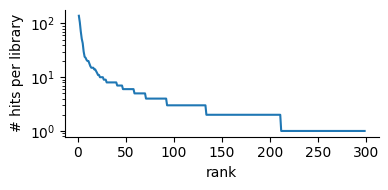

In [37]:
res_ = library_hits_count.sort_values(by='count', ascending=False).query('count > 0')
res_['rank'] = np.arange(1, len(res_) + 1)

# db.save_dataframe(
#     res_, table_name="site_rank_plot",
#     description="Ranking of sites depending on their detections"
# )

g = sns.relplot(
    data=res_,
    x='rank', y='count', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("rank")
g.set_ylabels("# hits per library")

### How many PAB detections per library?

As simple as the analysis above, but just analyzing PAB hits.

In [38]:
library_hits_count = bacteria_hits.query('is_pab == True').value_counts(['library', 'site', 'habitat']).reset_index()
library_hits_count['rank'] = np.arange(len(library_hits_count))
library_hits_count

,library,site,habitat,count,rank
0,PV215,L3,Edge,43,0
1,PV078,E4,Wasteland,37,1
2,PV527,Z2,Crop,28,2
3,PV212,L3,Edge,14,3
4,PV525,Z1,Crop,10,4
...,...,...,...,...,...
131,PV083,Q1,Oak,1,131
132,PV075,E2,Wasteland,1,132
133,PV174,L2,Edge,1,133
134,PV069,E1,Wasteland,1,134


In [39]:
pd.DataFrame.from_records(
    [
        {"threshold": "=1", "count": len(library_hits_count.query('count == 1'))},
        {"threshold": ">1", "count": len(library_hits_count.query('count > 1'))},
        {"threshold": ">2", "count": len(library_hits_count.query('count > 2'))},
        {"threshold": ">5", "count": len(library_hits_count.query('count > 5'))},
        {"threshold": ">10", "count": len(library_hits_count.query('count > 10'))},
    ]
)



,threshold,count
0,=1,62
1,>1,74
2,>2,50
3,>5,14
4,>10,4


Only 136 libraries were positive to PABs.

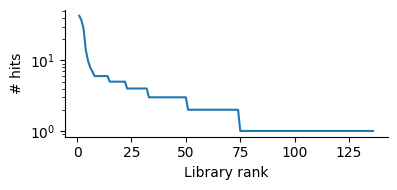

In [41]:
res_ = library_hits_count.sort_values(by='count', ascending=False).query('count > 0')
res_['rank'] = np.arange(1, len(res_) + 1)

# db.save_dataframe(
#     res_, table_name="site_rank_plot_PAB",
#     description="Ranking of sites depending on their detections of PAB OTUs"
# )

g = sns.relplot(
    data=res_,
    x='rank', y='count', kind='line',
    height=2.0, aspect=2.0
)
g.ax.set_yscale('log')
g.set_xlabels("Library rank")
g.set_ylabels("# hits")
g.savefig("figures/rankplot.pab-library.svg")

## Conclussions

1. We are able to detect 1486 bacteria hits, corresponding to 522 OTUs.
2. From those, around one third of the hits correspond to plant-associated bacteria. The total PAB OTUs are 127.
3. Most of the hits correspond to the order hyphomicrobiales, microccocales, burkhlodeliares, and pseudomonareales #TODO: check spelling.
4. Only 136 libraries (around half of them) were positive to PABs.

In [42]:
db.conn.close()